In [49]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [50]:
movies_ds = pd.read_csv("data/tmdb_5000_movies.csv")
credits_ds = pd.read_csv("data/tmdb_5000_credits.csv", low_memory = False)
# we see there are a bunch of extra commas in csv being treated as columns. let's get rid of these
credits_ds = credits_ds[["movie_id", "title", "cast", "crew"]]
df = movies_ds.merge(credits_ds, on = "title")
df_csv = df.to_csv("data/movies.csv", index = False)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

In [51]:
print(f"Dataset shape: {df.shape}")
print(f"First 5 rows:\n{df.head(5)}")

Dataset shape: (1492, 23)
First 5 rows:
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
3  250000000  [{"id": 28, "name": "Action"}, {"id": 80, "nam...   
4  260000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...  

In [52]:
import ast
# note that some columns are just a list of dictionaries, where the relevant data value is just the value
# where the key is "name". The number of columns are still correct, as the list items are also separated by commas
# genres is a list of dictionaries, but there are multiple so we must extract the name value at each dictionary
# this is for multiple columns, so let's create a function that does this for us
def clean_list_of_dics(column):
    list_of_dics_as_series = df[column]
    print(list_of_dics_as_series.dtype) # shows us that the list of dics is being stored as a string
    # so now we need to convert it into the expected actual list of dics, using ast.literal_eval()
    new_series = []
    for list_of_dics_str in list_of_dics_as_series:
        try:
            list_of_dics = ast.literal_eval(list_of_dics_str)
            values = []
            for index in range(0, len(list_of_dics)):
                dic = list_of_dics[index]
                if column != "crew": # we need job for crew also as we later filter crew column to only include director and Screenplay
                    value = dic["name"]
                    values.append(value)
                else:
                    value = (dic["name"], dic["job"])
                    values.append(value)
            new_series.append(values)
        except Exception as exc:
            new_series.append([])
            row_num = df.index[df[column] == list_of_dics_str]
            print(f"Error at row {row_num} for column {column} : {exc}")
    df[column] = new_series
cols_to_clean = ["genres", "keywords", "production_companies", "production_countries", "spoken_languages",
                     "cast", "crew"] # for cast, crew the only information really needed is their name
for col in cols_to_clean:
    clean_list_of_dics(col)


str
str
str
str
str
str
Error at row RangeIndex(start=218, stop=219, step=1) for column cast : unterminated string literal (detected at line 1) (<unknown>, line 1)
Error at row RangeIndex(start=598, stop=599, step=1) for column cast : unterminated string literal (detected at line 1) (<unknown>, line 1)
Error at row RangeIndex(start=637, stop=638, step=1) for column cast : unterminated string literal (detected at line 1) (<unknown>, line 1)
str
Error at row RangeIndex(start=28, stop=29, step=1) for column crew : unterminated string literal (detected at line 1) (<unknown>, line 1)
Error at row RangeIndex(start=212, stop=213, step=1) for column crew : '{' was never closed (<unknown>, line 1)
Error at row RangeIndex(start=0, stop=0, step=1) for column crew : malformed node or string: nan
Error at row RangeIndex(start=231, stop=232, step=1) for column crew : '{' was never closed (<unknown>, line 1)
Error at row RangeIndex(start=298, stop=299, step=1) for column crew : unterminated string li

In [53]:
print(df.head(5))

      budget                                         genres  \
0  237000000  [Action, Adventure, Fantasy, Science Fiction]   
1  300000000                   [Adventure, Fantasy, Action]   
2  245000000                     [Action, Adventure, Crime]   
3  250000000               [Action, Crime, Drama, Thriller]   
4  260000000           [Action, Adventure, Science Fiction]   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   
3            http://www.thedarkknightrises.com/   49026   
4          http://movies.disney.com/john-carter   49529   

                                            keywords original_language  \
0  [culture clash, future, space war, space colon...                en   
1  [ocean, drug abuse, exotic island, east india ...                en   
2  [spy, based on novel, secret agent, seque

In [54]:
print(df["release_date"].dtype)
df["release_date"] = pd.to_datetime(df["release_date"], format = "%d/%m/%Y")

str


In [55]:
# EDA
print(f"Summary statistics:\n{df.describe()}")
print(f"Missing values:\n{df.isnull().sum()}")
# Using domain knowledge, we can't really impute any homepage or tagline, and we also have missing values from when we cleaned lists of dictionaries
# so some cast and crew columns are going to be kept as [].
# we could have considered other options e.g. manually fixing formatting errors, or keeping cast/crew up to error.

Summary statistics:
             budget             id   popularity                release_date  \
count  1.492000e+03    1492.000000  1492.000000                        1492   
mean   7.252832e+07   42890.406836    38.344571  2005-05-07 12:57:54.530831   
min    0.000000e+00      12.000000     0.126738         1940-02-23 00:00:00   
25%    4.000000e+07    4906.000000    15.569893         2000-08-15 12:00:00   
50%    6.000000e+07   10589.500000    27.623185         2006-01-18 00:00:00   
75%    9.000000e+07   45421.750000    46.741251         2011-04-04 06:00:00   
max    3.800000e+08  417859.000000   875.581305         2016-08-17 00:00:00   
std    4.826435e+07   72426.264576    47.240472                         NaN   

            revenue      runtime  vote_average    vote_count  
count  1.492000e+03  1492.000000   1492.000000   1492.000000  
mean   1.972854e+08   114.646783      6.183713   1395.044906  
min    0.000000e+00     0.000000      0.000000      0.000000  
25%    4.796372e

In [56]:
# so for the missing homepage or tagline, let's just replace it with empty string
df["homepage"] = df["homepage"].fillna("")
df["tagline"] = df["tagline"].fillna("")

In [57]:
numeric_df = df.select_dtypes(include = "number")
numeric_df.drop(columns = ["id"])
print(numeric_df.head(5))

      budget      id  popularity     revenue  runtime  vote_average  \
0  237000000   19995  150.437577  2787965087    162.0           7.2   
1  300000000     285  139.082615   961000000    169.0           6.9   
2  245000000  206647  107.376788   880674609    148.0           6.3   
3  250000000   49026  112.312950  1084939099    165.0           7.6   
4  260000000   49529   43.926995   284139100    132.0           6.1   

   vote_count  
0       11800  
1        4500  
2        4466  
3        9106  
4        2124  


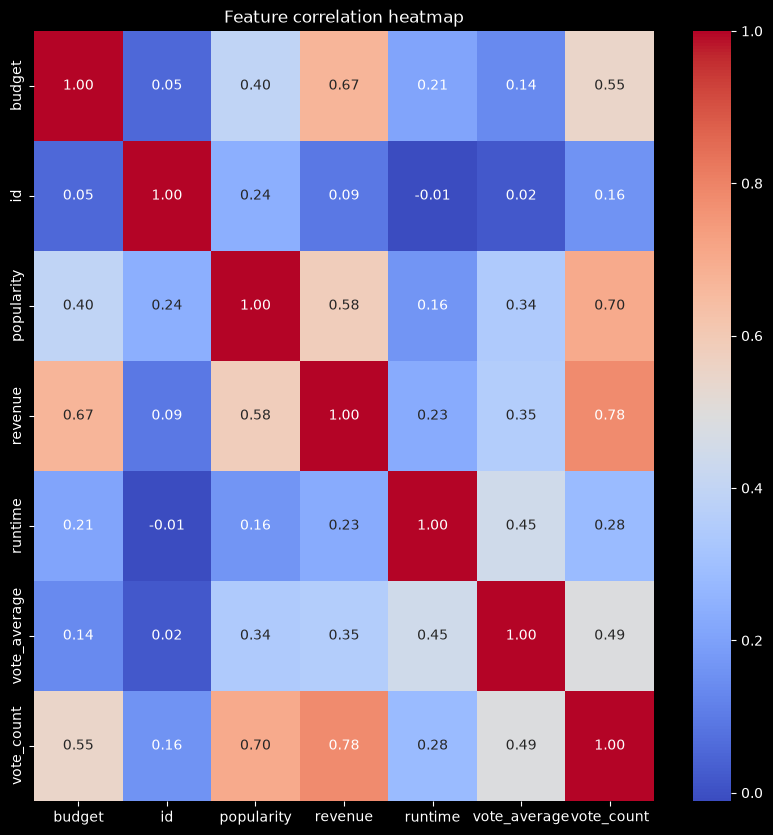

In [58]:
# feature correlation heatmap
plt.figure(figsize = (10,10))
sns.heatmap(numeric_df.corr(), annot = True, cmap = "coolwarm", fmt = ".2f")
plt.title("Feature correlation heatmap")
plt.show()


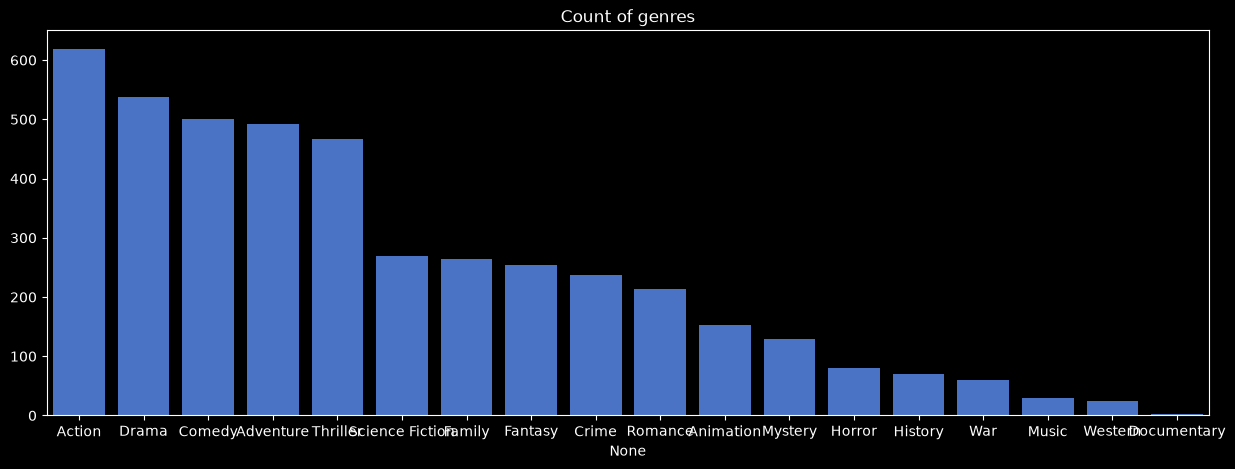

In [59]:
# bar chart showing count of each genre
all_genres = [genre for list in df["genres"] for genre in list]
genre_counts = pd.Series(all_genres).value_counts()
plt.figure(figsize = (15,5))
sns.barplot(x = genre_counts.index, y = genre_counts.values)
plt.title("Count of genres")
plt.show()

<Figure size 1000x1000 with 0 Axes>

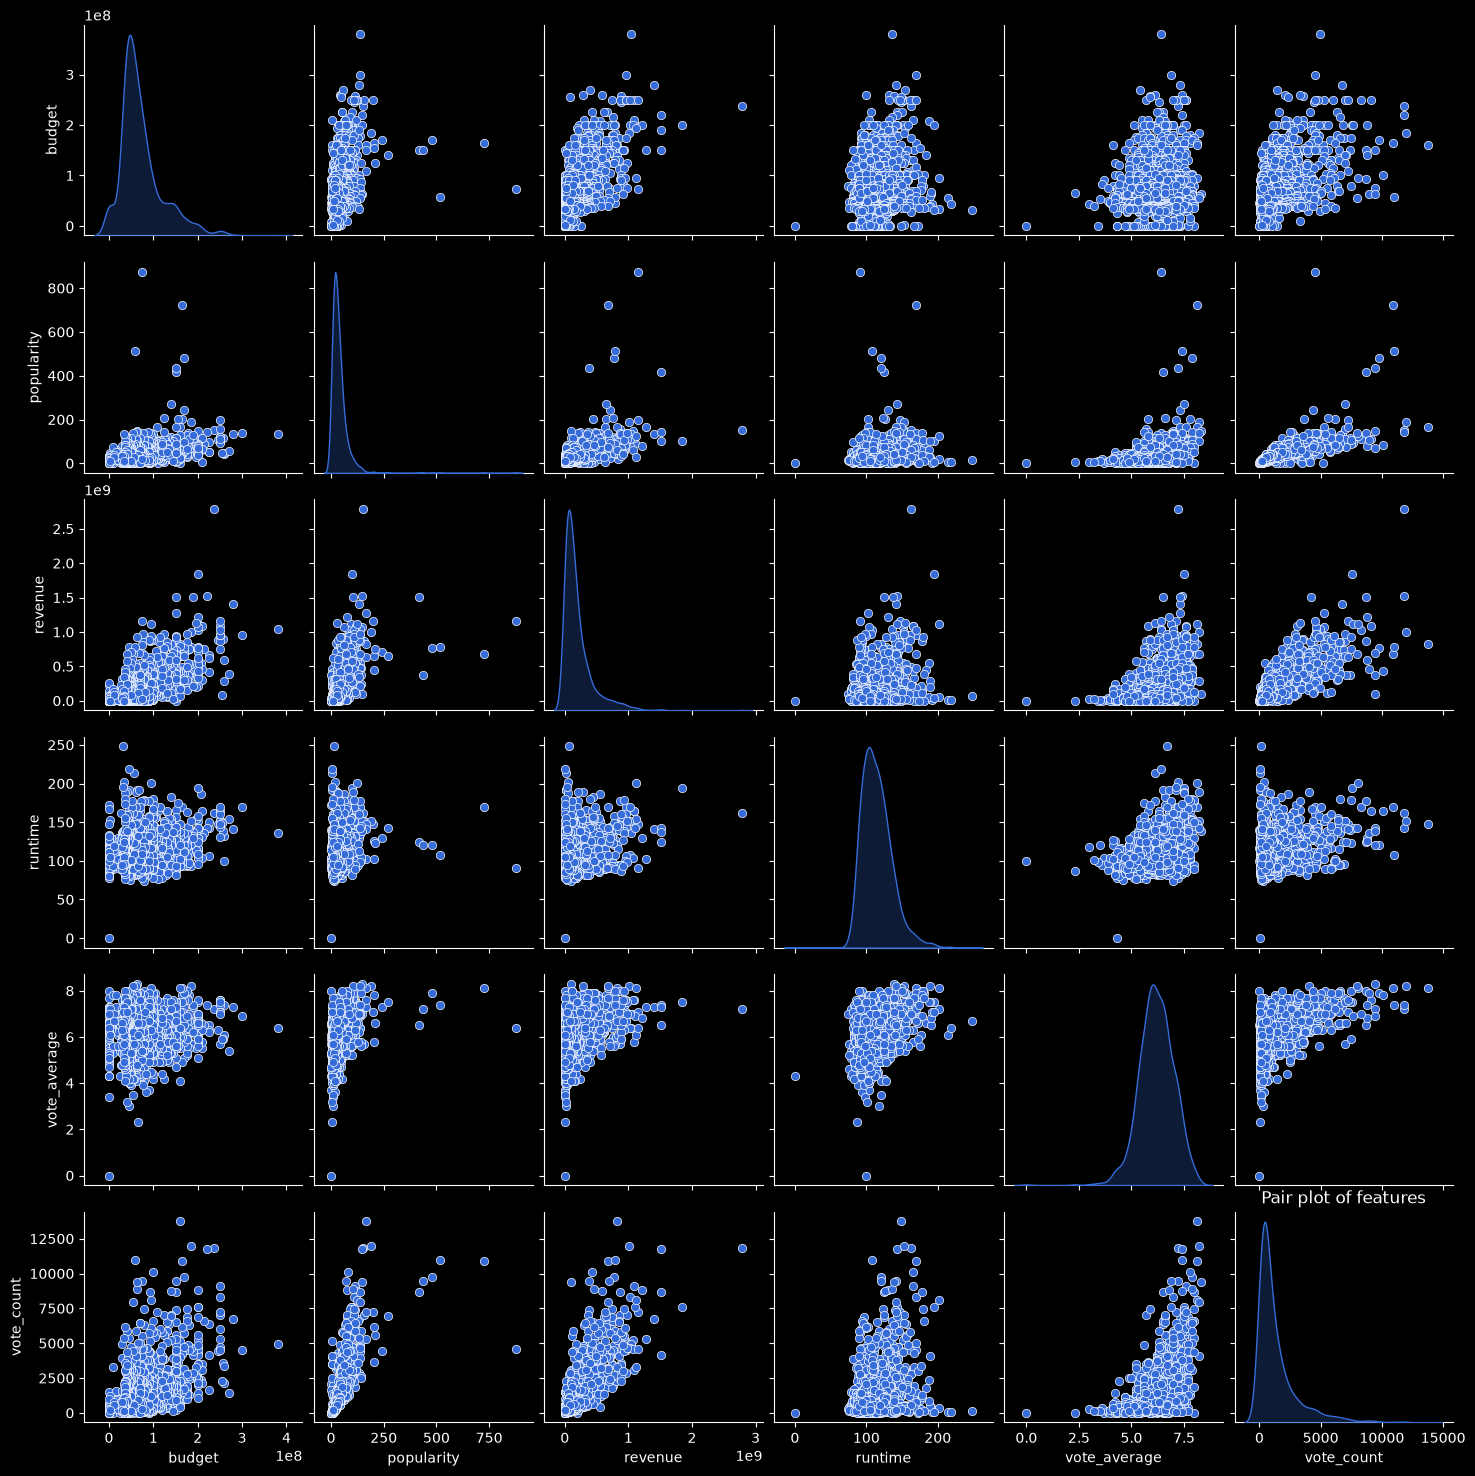

In [60]:
# Pairplot of features, no hue
plt.figure(figsize = (10,10))
sns.pairplot(data = df.drop(columns = ["homepage", "id"]), diag_kind = "kde")
plt.title("Pair plot of features")
plt.show()

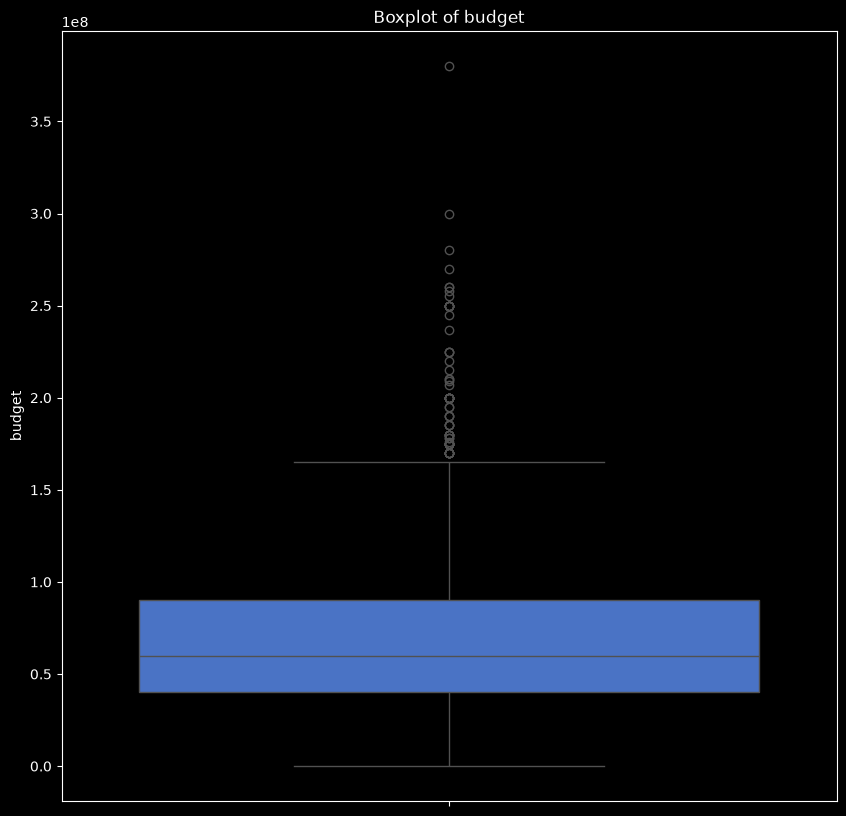

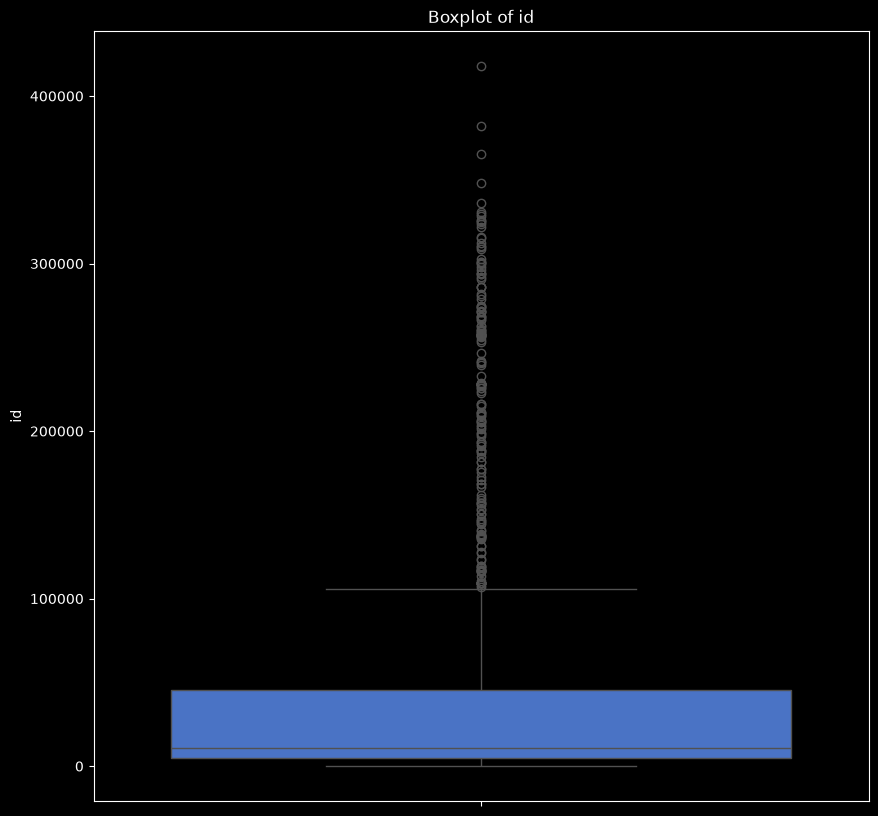

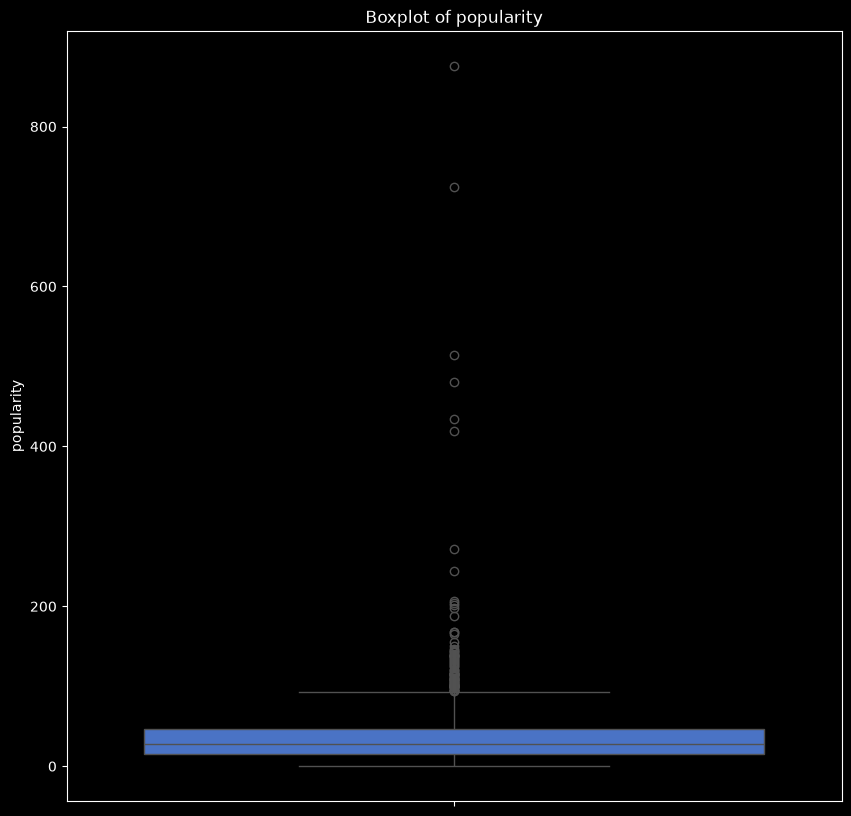

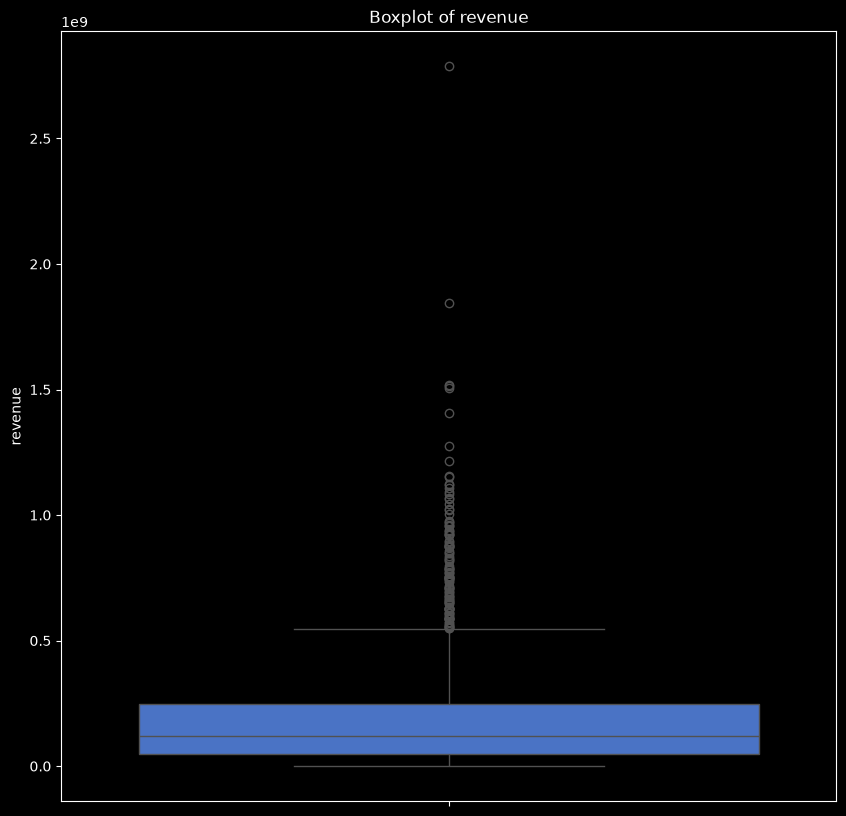

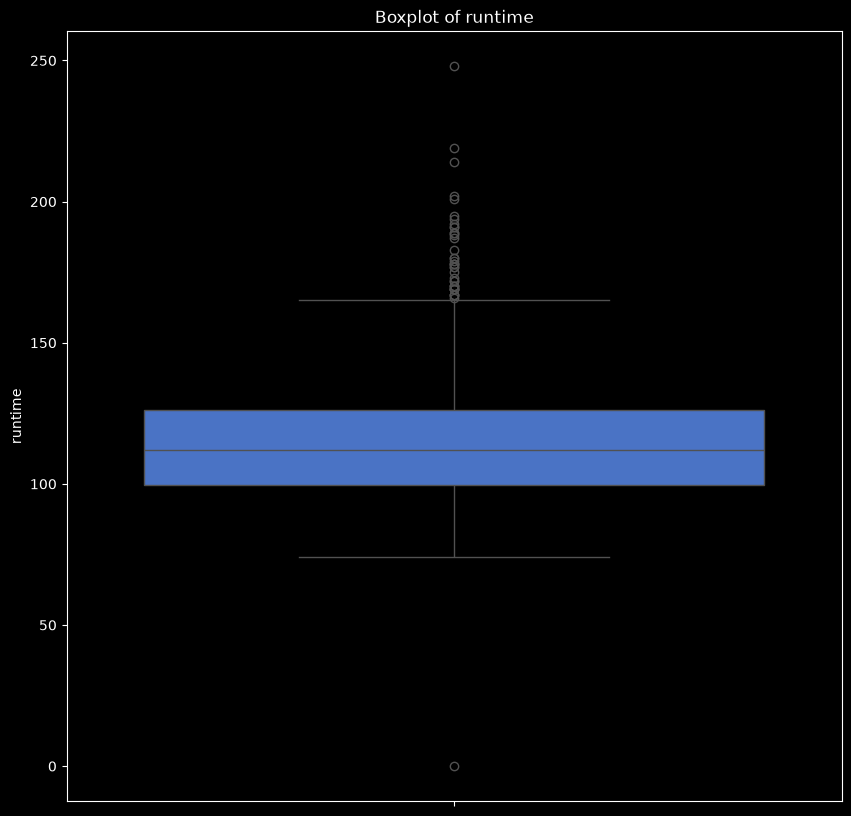

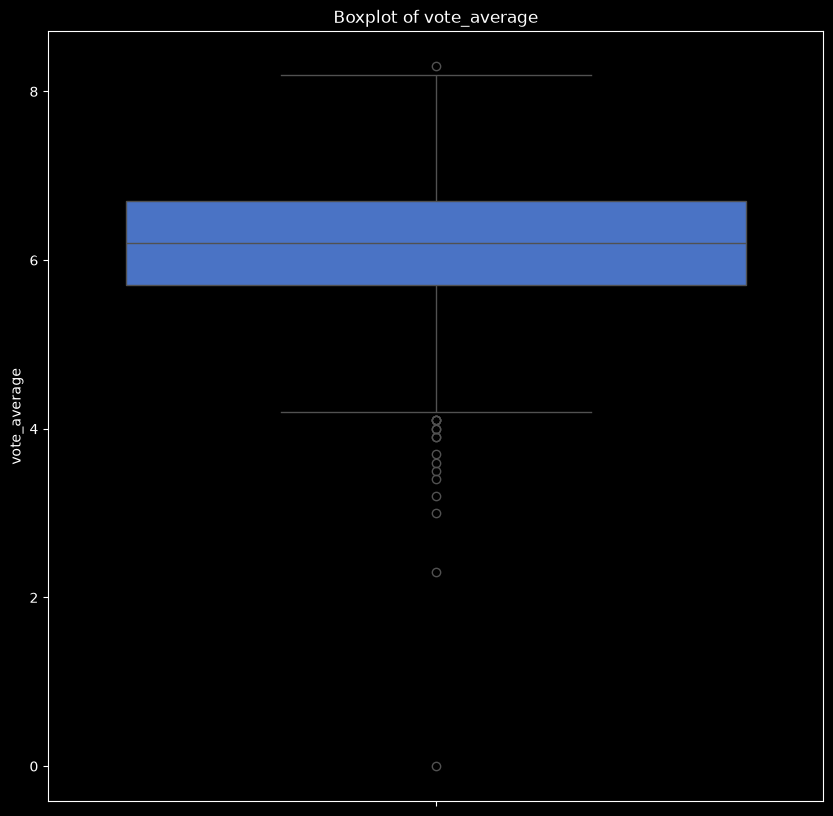

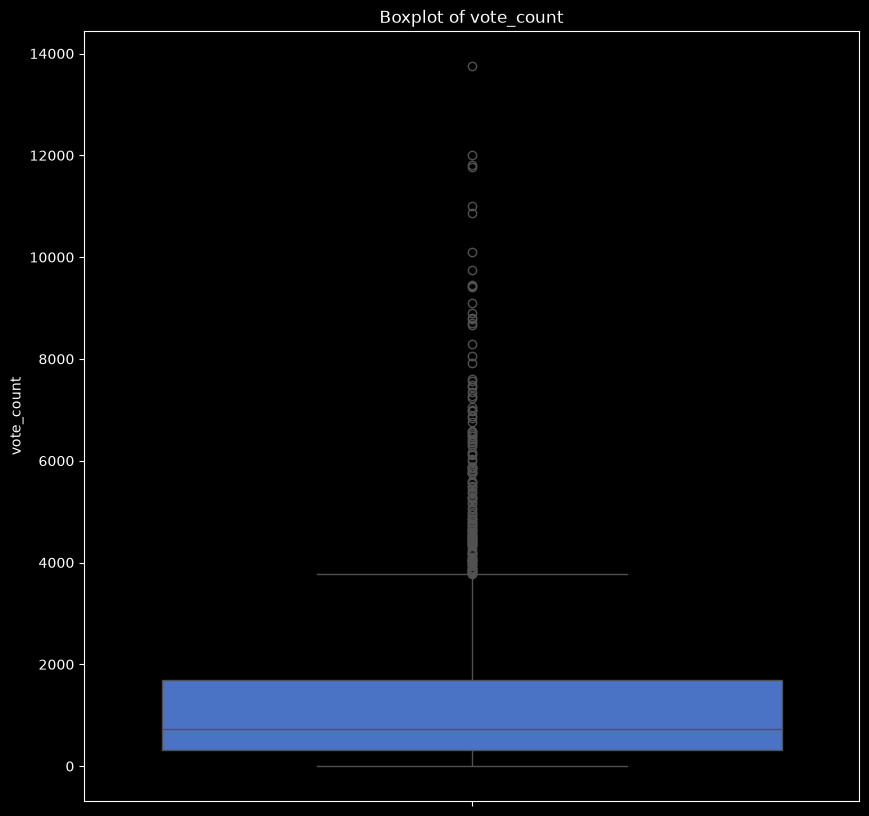

In [61]:
# Boxplots per feature
for col in numeric_df.columns.tolist():
    plt.figure(figsize = (10,10))
    sns.boxplot(data = numeric_df, y = col)
    plt.title(f"Boxplot of {col}")
    plt.show()

In [62]:
# Feature engineering on individual features
 # Let's remove keywords which appear in just one movie
print(df["keywords"].dtype)
# do this without a for loop for efficiency, use df.explode when value is a list
counts = df["keywords"].explode().value_counts()
df["keywords"] = df["keywords"].apply(
    lambda xs : [x for x in xs if counts[x] > 1] # apply works with any callable object, including lambda functions
    # xs is each list value in keywords, lambda [value at each row]
)

object


In [63]:
# some casts contain 100 members, as part of dimensionality reduction / feature space reduction for this column,
# we will only look at the the top 5 cast members ordered by 'order'
# we don't need access to the order field that was previously in the dictionary that we got rid of in clean_... function
# because they are actually in order of importance already in the csv file, so still will be here, i.e. order = index
print(df["cast"].dtype)
df["cast"] = df["cast"].apply(
    lambda xs : xs[:5]
)

object


In [64]:
# now we want to similarly filter crew, but to only include the director and screenplay, then we get just their name to reduce dimension even further!
# remember from clean function above, x here is just a tuple of (name, job)
print(df["crew"].dtype)
df["crew"] = df["crew"].apply(
    lambda xs : [x[0] for x in xs if x[1] == "Director" or x[1] == "Screenplay"]
)

object


In [65]:
# let's keep only the first 2 production companies (main ones)
print(df["production_companies"].dtype)
df["production_companies"] = df["production_companies"].apply(
    lambda xs : xs[:2]
)

object


In [66]:
from sklearn.impute import SimpleImputer
print(df[df["budget"] == 0])
# let's impute these
imputer = SimpleImputer(strategy = "mean")
df["budget"] = df["budget"].replace(0, np.nan)
df[["budget"]] = imputer.fit_transform(df[["budget"]])

      budget                                  genres  \
265        0               [Comedy, Fantasy, Family]   
321        0                                [Comedy]   
359        0  [Adventure, Animation, Comedy, Family]   
406        0      [Drama, Animation, Family, Comedy]   
409        0                          [Drama, Music]   
...      ...                                     ...   
1402       0            [Adventure, Comedy, Fantasy]   
1442       0                        [Drama, Romance]   
1453       0               [Fantasy, Family, Action]   
1462       0                                 [Drama]   
1464       0                          [Drama, Crime]   

                                               homepage      id  \
265                                                       10588   
321                                                       77953   
359   http://www.foxmovies.com/movies/alvin-and-the-...  258509   
406                     http://www.arthurchristmas.com/   5

In [67]:
# dimensionality reduction - remove columns that aren't useful - home page, original title, status (all are released)
df = df.drop(columns = ["homepage", "original_title", "status"])

In [68]:
print(df[df["revenue"] == 0])
# impute these using mean
imputer_revenue = SimpleImputer(strategy = "mean")
df["revenue"] = df["revenue"].replace(0, np.nan)
df[["revenue"]] = imputer_revenue.fit_transform(df[["revenue"]])
print(df[df["revenue"] == 0])

            budget                                             genres      id  \
83    2.700000e+07      [Action, Adventure, Science Fiction, Romance]   79698   
135   1.500000e+08                          [Drama, Horror, Thriller]    7978   
265   7.572586e+07                          [Comedy, Fantasy, Family]   10588   
309   8.400000e+07               [Fantasy, Comedy, Family, Adventure]   10214   
376   9.000000e+07         [Science Fiction, Action, Drama, Thriller]   10357   
...            ...                                                ...     ...   
1475  3.500000e+07                                  [Comedy, Romance]   77875   
1481  3.400000e+07            [Family, Fantasy, Animation, Adventure]  202575   
1485  3.300000e+07                                [Mystery, Thriller]   10685   
1489  3.300000e+07                                    [Comedy, Drama]   12596   
1491  1.377800e+06  [Family, Adventure, Comedy, Science Fiction, C...    2661   

                           

In [69]:
# convert columns where values are lists of strings into just strings
# now let's consider names, where each name needs to be one word with no spaces, just an underscore (standard practice)
# to be treated as one token, both first and last name concatted. this is for cast and crew cols.
# but also we can apply to keywords and genres, as some keywords are multi word phrases like 'space travel' or genres 'science fiction'
def list_to_string(column):
    if column in ["cast", "crew", "keywords", "genres"]:
        col_str = df[column].apply(
            lambda xs : " ".join(x.replace(" ", "_") for x in xs) # makes all spaces underscores in each element in the list
            # then joins the list.
        )
    else:
        col_str = df[column].apply(
            lambda xs : " ".join(xs)
        )
    return col_str
genres_series_str = list_to_string("genres")
keywords_series_str = list_to_string("keywords")
cast_series_str = list_to_string("cast")
crew_series_str = list_to_string("crew")
df["tags"] = (genres_series_str + " " + genres_series_str + " " + keywords_series_str + " " + cast_series_str + " "
+ crew_series_str + " " + df["overview"] + " " + df["tagline"]) # we repeated genres_series_str to weigh more importance on genre
# Chosen to include genre, keywords, cast, crew, overview and tagline as the main tokenised words that make up a movie
# This many could add some noise to deal with though.

In [70]:
# clean text / normalise
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download nltk resources
nltk.download("stopwords", quiet = True)
nltk.download("wordnet", quiet = True)
nltk.download("omw-1.4", quiet = True)
def clean_text(text):
    if pd.isnull(text):
        return ""
    try:
        text = str(text)
        text = re.sub(r"https\S+|www\S+|https\S+", "", text, flags = re.MULTILINE) # remove URLS
        text = re.sub(r"@\w+|#\w+", "", text) # removes @s and #s
        text = re.sub(r"[^\w\s]", "", text) # removes special characters apart from basic punctuation
        text = text.lower() # converts to lowercase
        text = re.sub(r"\d+", "", text) # removes all numbers
        text = " ".join(text.split()) # removes extra white space
        return text
    except Exception as exc:
        print(f"Error cleaning text: {exc}")
        return ""

# initialise lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words =set(stopwords.words("english"))

def preprocess_text(text):
    try:
        text = clean_text(text)
        if not text.strip(): # if string is empty
            return ""
        # tokenize and lemmatize
        tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in stop_words and len(word) > 2]
        return " ".join(tokens)
    except Exception as exc:
        print(f"Error preprocessing text: {exc}")
        return ""

print("Preprocessing movie data...")
df["cleaned_tags"] = df["tags"].apply(preprocess_text)
initial_count = len(df)
df = df[df["cleaned_tags"].str.strip() != ""] # filters out rowswhere cleaned_tags is emptyafter stripping
print(f"Removed {initial_count - len(df)} rows with empty/missing data")


Preprocessing movie data...
Removed 0 rows with empty/missing data


In [71]:
# vectorize data using tf-idf and then compute cosine similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
df = df.reset_index(drop = True) # ensures positions line up with similarity matrix rows even after dropping rows
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(df["cleaned_tags"]) # contains a vector representation of every movie
similarity = cosine_similarity(tfidf_matrix) # cosine similarity effective for text as focus on direction, measures angle rather than magnitude



In [72]:
import pickle
# save model
movies = df[["title", "genres", "vote_average", "release_date", "popularity"]].reset_index(drop = True) # these are the columns that will be displayed in the app
pickle.dump(movies, open("movies.pkl", "wb")) # saves movies df into movies.pkl
pickle.dump(similarity, open("similarity.pkl", "wb")) # saves similarity matrix into similarity.pkl, app can just look up movie A's row e.g.


In [73]:
df.to_csv("data/cleaned_dataset.csv", index = False)